In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
### Lab PC
# === Load Train and Test Data ===
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")

### LSTM

In [4]:
# ─────── Hyperparameters ───────
SEQ_LEN     = 60        # Length of input sequence (seconds)
BATCH_SIZE  = 64        # Batch size for training
HIDDEN_SIZE = 64        # Number of hidden units in LSTM
NUM_LAYERS  = 2         # Number of LSTM layers
DROPOUT     = 0.2       # Dropout rate between LSTM layers
LR          = 1e-3      # Learning rate for Adam optimizer
MAX_EPOCHS  = 50        # Maximum number of training epochs
PATIENCE    = 10         # Early stopping patience

In [5]:
FEATURES = [
    "Ambient Temp Trace(F)",
    "Inlet Temp Trace(F)",
    "Outlet Temp Trace (F)",
    "Operational Mode Code",
]
TARGET = "Power (W)"

# ─────── Device configuration ───────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────── Load and scale data ───────
#train_df = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Trian\Trian\Merged_HPWH_Train_1s.csv")
#test_df  = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Test\Test\Merged_HPWH_Test_1s.csv")

### Desktop
train_df = pd.read_csv(r"C:\Users\13183\Downloads\Trian 1\Trian\Merged_HPWH_Train_1s.csv")
test_df  = pd.read_csv(r"C:\Users\13183\Downloads\Test 1\Test\Merged_HPWH_Test_1s.csv")
train_df[TARGET] = -train_df[TARGET]
test_df[TARGET]  = -test_df[TARGET]
####Lab PC
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit scalers on the training set and transform both the train and test
X_train = scaler_x.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).squeeze(-1)
X_test  = scaler_x.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).squeeze(-1)

# ─────── Dataset definition ───────
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        # Store as tensors; slicing will happen in __getitem__
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        # Number of samples is total length minus one sequence
        return self.X.size(0) - self.seq_len

    def __getitem__(self, idx):
        # Return one sequence window and its target value
        x_seq = self.X[idx : idx + self.seq_len]  # Shape: [seq_len, num_features]
        y_val = self.y[idx + self.seq_len]        # Scalar target
        return x_seq, y_val

# Instantiate datasets and loaders
train_ds = SequenceDataset(X_train, y_train, SEQ_LEN)
test_ds  = SequenceDataset(X_test,  y_test,  SEQ_LEN)
print("Train samples:", len(train_ds), "Test samples:", len(test_ds))

Using device: cuda
Train samples: 176281 Test samples: 50281


In [6]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True
)

# ─────── Model definition ───────
class HPWH_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        # Stacked LSTM with dropout between layers
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        # Final linear layer to map hidden state to output
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        _, (h_n, _) = self.lstm(x)
        # Use the last layer's final hidden state
        out = self.fc(h_n[-1])
        return out.squeeze(-1)  # Shape: [batch]

# Create model, loss, and optimizer
model = HPWH_LSTM(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ─────── Training loop with early stopping ───────
best_val_loss = float("inf")
no_improve    = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # ---- Training ----
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}", leave=False)
    for Xb, yb in loop:
        # Move batch to the correct device
        Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
        loop.set_postfix(loss=loss.item())
    train_loss /= len(train_loader.dataset)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            preds = model(Xb)
            val_loss += criterion(preds, yb).item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}")
        # ---- Early stopping check ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), "best_hpwh_lstm.pt")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

Epoch 01 | Train MSE: 0.03094 | Val MSE: 0.05100


Epoch 02 | Train MSE: 0.02659 | Val MSE: 0.05192


Epoch 03 | Train MSE: 0.02043 | Val MSE: 0.05776


Epoch 04 | Train MSE: 0.01388 | Val MSE: 0.05044


Epoch 05 | Train MSE: 0.01337 | Val MSE: 0.06192


...

Epoch 10 | Train MSE: 0.00547 | Val MSE: 0.12004


Epoch 11 | Train MSE: 0.00500 | Val MSE: 0.10163


Epoch 12 | Train MSE: 0.00979 | Val MSE: 0.08778


Epoch 13 | Train MSE: 0.01134 | Val MSE: 0.05135


Epoch 14 | Train MSE: 0.00694 | Val MSE: 0.05871
Early stopping at epoch 14 (no improvement for 10 epochs).



Test MAE: 33.06 W | RMSE: 58.63 W | NRMSE: 0.2250 | R^2: 0.344


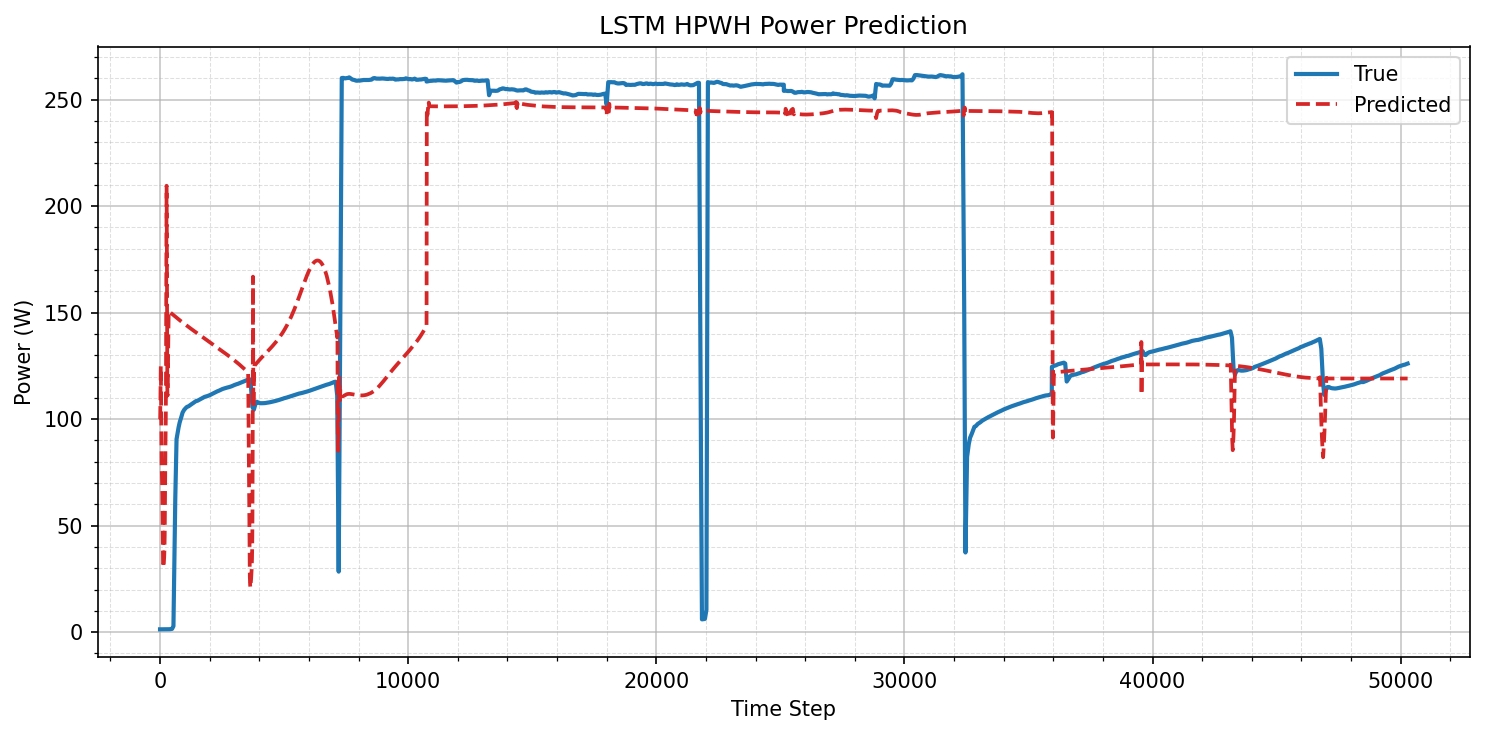

In [7]:
# ─────── Load best model & evaluate ───────
# Load the best saved weights and switch the model to eval mode (disables dropout, etc.)
model.load_state_dict(torch.load("best_hpwh_lstm.pt"))
model.eval()

y_true_list, y_pred_list = [], []

# Inference without gradient tracking (saves memory and speeds up evaluation)
with torch.no_grad():
    for Xb, yb in test_loader:
        # Move inputs to the correct device (CPU/GPU)
        Xb = Xb.to(device)

        # Forward pass -> predictions (move back to CPU before converting to NumPy)
        preds = model(Xb).cpu().numpy()

        # Collect ground-truth and predictions for this batch
        y_true_list.append(yb.numpy())
        y_pred_list.append(preds)

# ─────── Concatenate batches and inverse-transform to original scale ───────
# Stack all batches into single arrays and reshape to 2D for the scaler
y_true_scaled = np.concatenate(y_true_list).reshape(-1, 1)
y_pred_scaled = np.concatenate(y_pred_list).reshape(-1, 1)

# Inverse transform from scaled space back to original units (Watts)
y_true = scaler_y.inverse_transform(y_true_scaled).ravel()
y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

# Optional safety: if power must be non-negative, uncomment the two lines below
# y_true = np.clip(y_true, 0, None)
# y_pred = np.clip(y_pred, 0, None)

# ─────── Compute metrics ───────
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)

# Normalized RMSE: divide by the dynamic range of the true signal
nrmse = rmse / (np.max(y_true) - np.min(y_true) + 1e-12)  # small eps for safety

print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")

# ─────── Plot predictions vs. actual ───────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=150)

# Colors/linestyles to match your reference:
#   - True:   blue solid
#   - Predicted: red dashed
plt.plot(y_true, label="True", color="tab:blue", linewidth=2.0)
plt.plot(y_pred, label="Predicted", color="tab:red", linestyle="--", linewidth=1.8)

# Grid styling (major + minor)
ax = plt.gca()
ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)

plt.legend(loc="best")
plt.title("LSTM HPWH Power Prediction")
plt.xlabel("Time Step")
plt.ylabel("Power (W)")
plt.tight_layout()
plt.show()

In [ ]:
# # ─────── Load best model & evaluate ───────
# model.load_state_dict(torch.load("best_hpwh_lstm.pt"))
# model.eval()

# y_true_list, y_pred_list = [], []
# with torch.no_grad():
#     for Xb, yb in test_loader:
#         Xb = Xb.to(device)
#         preds = model(Xb).cpu().numpy()  # Move to CPU before converting
#         y_true_list.append(yb.numpy())
#         y_pred_list.append(preds)

# # Concatenate batches and inverse-transform
# y_true_scaled = np.concatenate(y_true_list).reshape(-1, 1)
# y_pred_scaled = np.concatenate(y_pred_list).reshape(-1, 1)

# y_true = scaler_y.inverse_transform(y_true_scaled).ravel()
# y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

# mae  = mean_absolute_error(y_true, y_pred)
# mse  = mean_squared_error(y_true, y_pred)
# rmse = np.sqrt(mse)
# r2   = r2_score(y_true, y_pred)
# nrmse = rmse / (np.max(y_true) - np.min(y_true))  # NRMSE calculation
# print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")

# # ─────── Plot predictions vs. actual ───────
# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(y_pred, label="Predicted")
# plt.plot(y_true, label="Actual")
# plt.legend()
# plt.title("LSTM HPWH Power Prediction")
# plt.xlabel("Time Step")
# plt.ylabel("Power (W)")
# plt.show()

### Capture Spike -LSTM

Using device: cuda
Detected 6 spike samples out of 176341 total.


Epoch 01 | Train W-MSE: 0.03078 | Val MSE: 0.08371


Epoch 02 | Train W-MSE: 0.01776 | Val MSE: 0.09808


Epoch 03 | Train W-MSE: 0.01542 | Val MSE: 0.08515


Epoch 04 | Train W-MSE: 0.01532 | Val MSE: 0.10378


...

Epoch 07 | Train W-MSE: 0.01192 | Val MSE: 0.09783


Epoch 08 | Train W-MSE: 0.01467 | Val MSE: 0.09946


Epoch 09 | Train W-MSE: 0.00689 | Val MSE: 0.12734


Epoch 10 | Train W-MSE: 0.00729 | Val MSE: 0.11373


Epoch 11 | Train W-MSE: 0.00766 | Val MSE: 0.10166
Early stopping at epoch 11.

Test MAE: 48.72 W | RMSE: 75.53 W | NRMSE: 0.2899 | R^2: -0.089


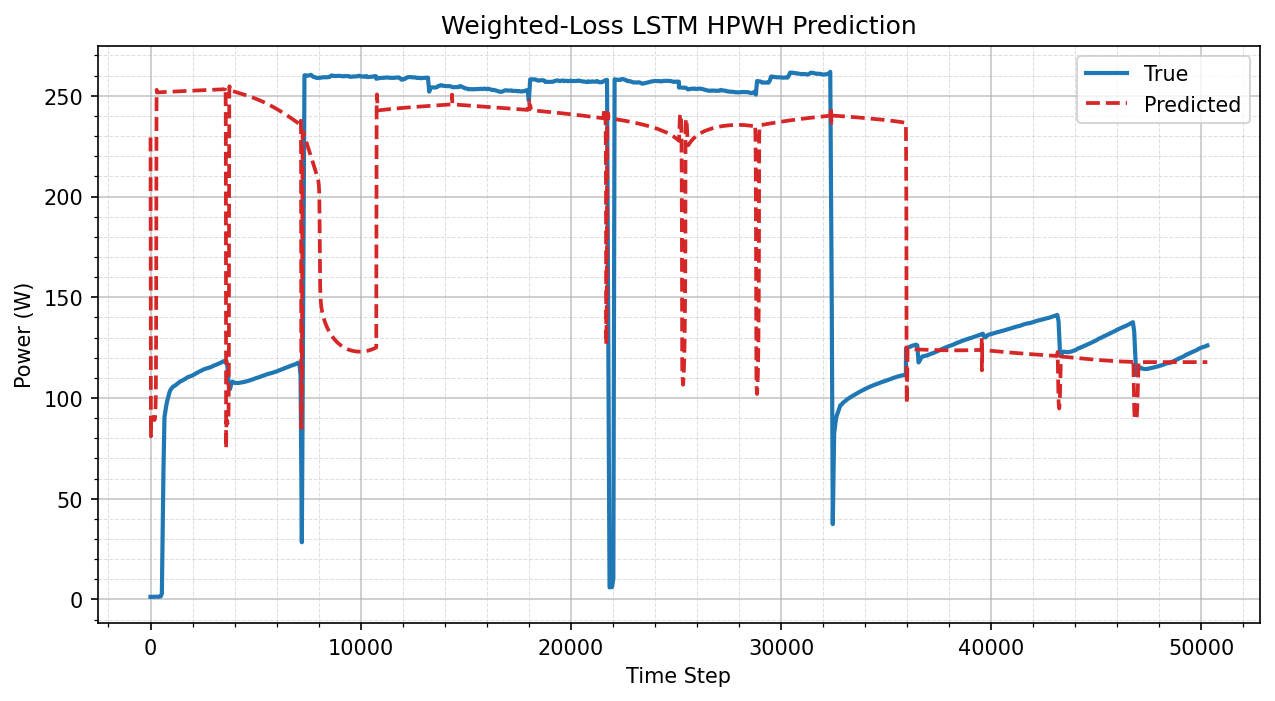

In [9]:
# hpwh_lstm_weighted_spikes_full.py

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ───── Hyperparameters ─────
SEQ_LEN      = 60        # Number of time steps per sample
BATCH_SIZE   = 64
HIDDEN_SIZE  = 64
NUM_LAYERS   = 2
DROPOUT      = 0.3
LR           = 1e-3
MAX_EPOCHS   = 50
PATIENCE     = 10
SPIKE_WEIGHT = 5.0       # Weight multiplier for spike samples
SPIKE_K      = 4    # Threshold: |Δy| > K * std(Δy) marks a spike

FEATURES = [
    "Ambient Temp Trace(F)",
    "Inlet Temp Trace(F)",
    "Outlet Temp Trace (F)",
    "Operational Mode Code",
]
TARGET = "Power (W)"

# ───── Device configuration ─────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ───── Load & normalize data ─────
##Home PC
#train_df = pd.read_csv( r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Trian\Trian\Merged_HPWH_Train_1s.csv")
#test_df = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Test\Test\Merged_HPWH_Test_1s.csv")

### Desktop
train_df = pd.read_csv(r"C:\Users\13183\Downloads\Trian 1\Trian\Merged_HPWH_Train_1s.csv")
test_df  = pd.read_csv(r"C:\Users\13183\Downloads\Test 1\Test\Merged_HPWH_Test_1s.csv")
train_df[TARGET] = -train_df[TARGET]
test_df[TARGET]  = -test_df[TARGET]

####Lab PC
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_x.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).ravel()
X_test  = scaler_x.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).ravel()

# ───── Detect spikes events & assign weights ─────
# Compute absolute first-differences
dy = np.abs(np.diff(y_train, prepend=y_train[0]))
threshold = SPIKE_K * np.std(dy)
is_spike = (dy > threshold).astype(float)
print(f"Detected {int(is_spike.sum())} spike samples out of {len(is_spike)} total.")

# Build per-sample weight vector
weights = np.where(is_spike > 0, SPIKE_WEIGHT, 1.0)

# ─────Dataset definition ─────
class SequenceDataset(Dataset):
    def __init__(self, X, y, w, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.w = torch.tensor(w, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]    # [seq_len, features]
        y_val = self.y[idx + self.seq_len]          # scalar target
        w_val = self.w[idx + self.seq_len]          # scalar weight
        return x_seq, y_val, w_val

train_ds = SequenceDataset(X_train, y_train, weights, SEQ_LEN)
test_ds  = SequenceDataset(X_test,  y_test,  np.ones_like(y_test), SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# ─────LSTM model ─────
class HPWH_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, seq_len, features]
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out.squeeze(-1)  # [batch]

model = HPWH_LSTM(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

# ───── Weighted MSE loss ─────
def weighted_mse(pred, target, weight):
    return torch.mean(weight * (pred - target) ** 2)

optimizer = optim.Adam(model.parameters(), lr=LR)

# ───── Training loop with early stopping ─────
best_val_loss = float("inf")
wait = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # -- train --
    model.train()
    train_loss = 0.0
    for Xb, yb, wb in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        Xb, yb, wb = Xb.to(device), yb.to(device), wb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss = weighted_mse(preds, yb, wb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)

    # -- validate (unweighted MSE) --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb, _ in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            preds = model(Xb)
            val_loss += nn.MSELoss()(preds, yb).item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch:02d} | Train W-MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}")

    # early stopping on validation MSE
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_weighted_lstm.pt")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

# ───── Load best model & final evaluation ─────
model.load_state_dict(torch.load("best_weighted_lstm.pt"))
model.eval()

y_true_list, y_pred_list = [], []
with torch.no_grad():
    for Xb, yb, _ in test_loader:
        Xb = Xb.to(device)
        preds = model(Xb).cpu().numpy()
        y_true_list.append(yb.numpy())
        y_pred_list.append(preds)

y_true = scaler_y.inverse_transform(
    np.concatenate(y_true_list).reshape(-1, 1)
).ravel()
y_pred = scaler_y.inverse_transform(
    np.concatenate(y_pred_list).reshape(-1, 1)
).ravel()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
nrmse = rmse / (y_true.max() - y_true.min())
print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")


# ───── Plot predicted vs. actual ─────
plt.figure(figsize=(10, 5), dpi=150)

# Colors/linestyles to match your reference:
#   - True:   blue solid
#   - Predicted: red dashed
plt.plot(y_true, label="True", color="tab:blue", linewidth=2.0)
plt.plot(y_pred, label="Predicted", color="tab:red", linestyle="--", linewidth=1.8)

# Grid styling (major + minor)
ax = plt.gca()
ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.legend()
plt.title("Weighted-Loss LSTM HPWH Prediction")
plt.xlabel("Time Step")
plt.ylabel("Power (W)")
plt.show()

### GRU

Using device: cuda


[GRU] Epoch 01 | Train MSE: 0.02951 | Val MSE: 0.06635


[GRU] Epoch 02 | Train MSE: 0.01708 | Val MSE: 0.07837


[GRU] Epoch 03 | Train MSE: 0.01230 | Val MSE: 0.08659


[GRU] Epoch 04 | Train MSE: 0.01293 | Val MSE: 0.12229


...

[GRU] Epoch 07 | Train MSE: 0.00672 | Val MSE: 0.11081


[GRU] Epoch 08 | Train MSE: 0.00808 | Val MSE: 0.11404


[GRU] Epoch 09 | Train MSE: 0.00585 | Val MSE: 0.10585


[GRU] Epoch 10 | Train MSE: 0.00496 | Val MSE: 0.12804


[GRU] Epoch 11 | Train MSE: 0.00510 | Val MSE: 0.10928
Early stopping GRU.

Test MAE: 39.60 W | RMSE: 67.25 W | NRMSE: 0.2581 | R^2: 0.137


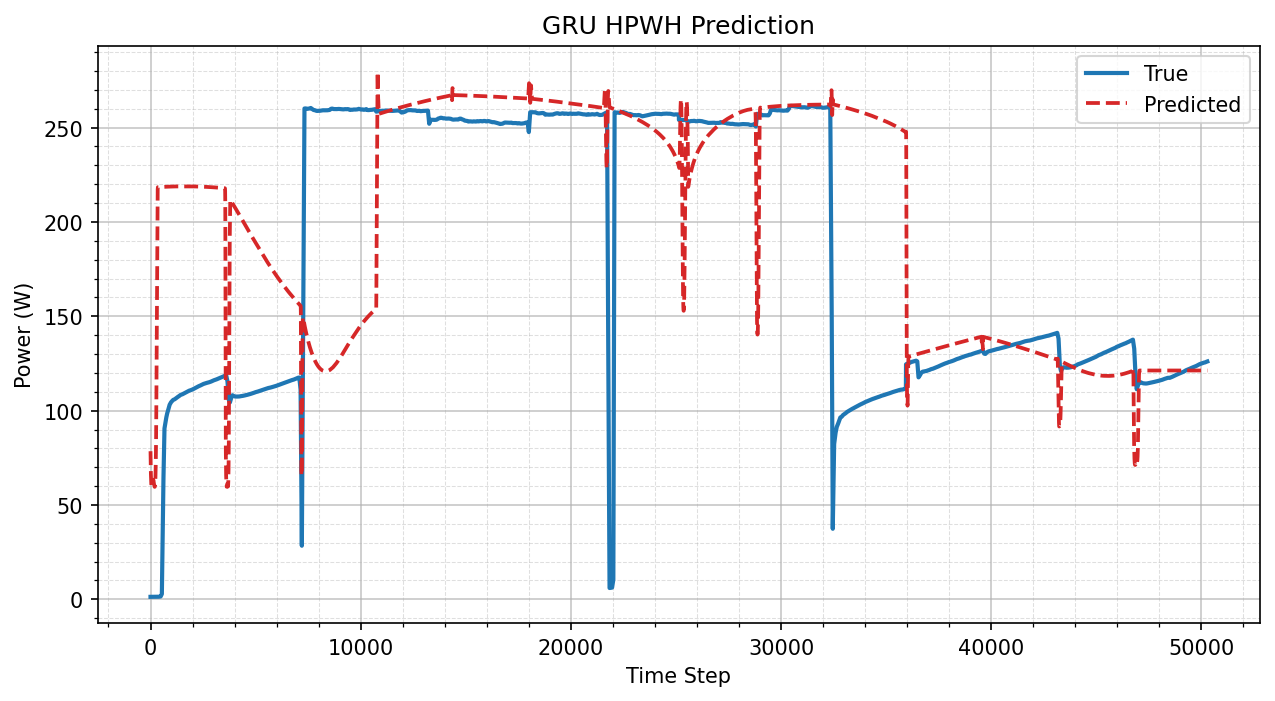

In [11]:
# hpwh_gru.py

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ───── Hyperparameters ─────
SEQ_LEN     = 60
BATCH_SIZE  = 64
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.3
LR          = 1e-3
MAX_EPOCHS  = 50
PATIENCE    = 10

FEATURES = [
    "Ambient Temp Trace(F)",
    "Inlet Temp Trace(F)",
    "Outlet Temp Trace (F)",
    "Operational Mode Code",
]
TARGET = "Power (W)"

# ───── Device ─────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ───── Load & Scale ─────
####Lab PC
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")

###Home PC
#train_df = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Trian\Trian\Merged_HPWH_Train_1s.csv")
# test_df  = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Test\Test\Merged_HPWH_Test_1s.csv")

### Desktop
train_df = pd.read_csv(r"C:\Users\13183\Downloads\Trian 1\Trian\Merged_HPWH_Train_1s.csv")
test_df  = pd.read_csv(r"C:\Users\13183\Downloads\Test 1\Test\Merged_HPWH_Test_1s.csv")
train_df[TARGET] = -train_df[TARGET]
test_df[TARGET]  = -test_df[TARGET]

scaler_x = MinMaxScaler(); scaler_y = MinMaxScaler()
X_train = scaler_x.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).squeeze(-1)
X_test  = scaler_x.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).squeeze(-1)

# ───── Dataset ─────
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
    def __len__(self):
        return self.X.size(0) - self.seq_len
    def __getitem__(self, idx):
        return (
            self.X[idx:idx+self.seq_len],   # [seq_len, features]
            self.y[idx+self.seq_len]        # scalar
        )

train_ds = SequenceDataset(X_train, y_train, SEQ_LEN)
test_ds  = SequenceDataset(X_test,  y_test,  SEQ_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# ───── Model ─────
class HPWH_GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        # x: [batch, seq_len, features]
        _, h_n = self.gru(x)
        # h_n: [num_layers, batch, hidden_size]
        out = self.fc(h_n[-1])           # use last layer
        return out.squeeze(-1)           # [batch]

model = HPWH_GRU(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ───── Training Loop ─────
best_val = float('inf'); wait = 0
for epoch in range(1, MAX_EPOCHS+1):
    model.train(); train_loss = 0.
    for Xb, yb in tqdm(train_loader, desc=f"GRU Epoch {epoch}/{MAX_EPOCHS}", leave=False):
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(Xb)
        loss  = criterion(preds, yb)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval(); val_loss = 0.
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"[GRU] Epoch {epoch:02d} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}")
    if val_loss < best_val:
        best_val = val_loss; wait = 0
        torch.save(model.state_dict(), "best_gru.pt")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping GRU.")
            break

# ───── Evaluate ─────
model.load_state_dict(torch.load("best_gru.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        out = model(Xb).cpu().numpy()
        y_pred.append(out); y_true.append(yb.numpy())
y_true = scaler_y.inverse_transform(np.concatenate(y_true).reshape(-1,1)).ravel()
y_pred = scaler_y.inverse_transform(np.concatenate(y_pred).reshape(-1,1)).ravel()
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_true, y_pred)
nrmse = rmse / (np.max(y_true) - np.min(y_true))  # NRMSE calculation
print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")

# ───── Plot ─────
# plt.figure()
# plt.plot(y_pred, label="Pred")
# plt.plot(y_true, label="True")
# ───── Plot predicted vs. actual ─────
plt.figure(figsize=(10, 5), dpi=150)

# Colors/linestyles to match your reference:
#   - True:   blue solid
#   - Predicted: red dashed
plt.plot(y_true, label="True", color="tab:blue", linewidth=2.0)
plt.plot(y_pred, label="Predicted", color="tab:red", linestyle="--", linewidth=1.8)

# Grid styling (major + minor)
ax = plt.gca()
ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.title("GRU HPWH Prediction")
plt.xlabel("Time Step"); plt.ylabel("Power (W)")
plt.legend(); plt.show()

### 1D_CNN

[CNN] Ep01 Train MSE:0.02496 Val MSE:0.35561


[CNN] Ep02 Train MSE:0.01308 Val MSE:0.29383


[CNN] Ep03 Train MSE:0.01026 Val MSE:0.18405


[CNN] Ep04 Train MSE:0.00889 Val MSE:0.14928


[CNN] Ep05 Train MSE:0.00828 Val MSE:0.20892


...

[CNN] Ep16 Train MSE:0.00659 Val MSE:24.69539


[CNN] Ep17 Train MSE:0.00640 Val MSE:35.82586


[CNN] Ep18 Train MSE:0.00637 Val MSE:48.88180


[CNN] Ep19 Train MSE:0.00639 Val MSE:55.91916


[CNN] Ep20 Train MSE:0.00630 Val MSE:59.36682
Early stopping CNN.

Test MAE: 35.60 W | RMSE: 60.16 W | NRMSE: 0.2309 | R^2: 0.309


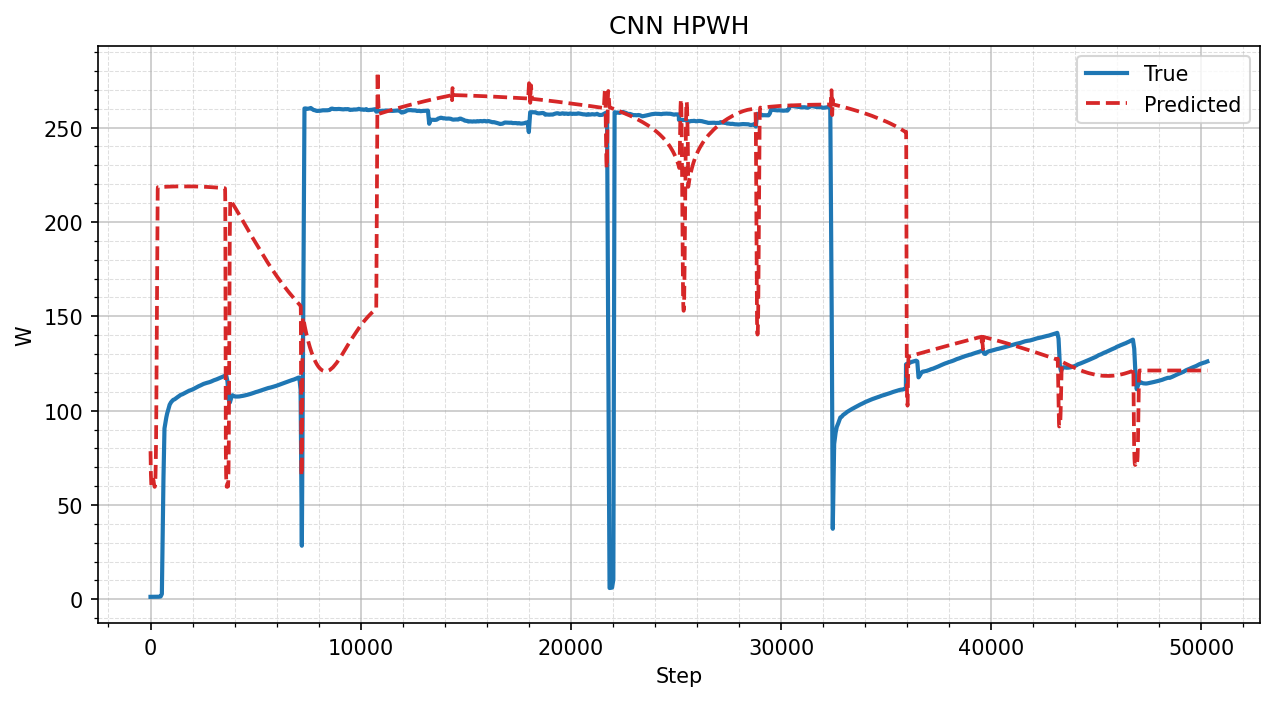

In [12]:
# hpwh_cnn.py

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ───── Hyperparameters ─────
SEQ_LEN     = 60
BATCH_SIZE  = 64
NUM_FILTERS = 64
KERNEL_SIZE = 3
DROPOUT     = 0.3
LR          = 1e-3
MAX_EPOCHS  = 50
PATIENCE    = 10

FEATURES = [
    "Ambient Temp Trace(F)",
    "Inlet Temp Trace(F)",
    "Outlet Temp Trace (F)",
    "Operational Mode Code",
]
TARGET = "Power (W)"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ───── Load & Scale ─────
### Desktop
train_df = pd.read_csv(r"C:\Users\13183\Downloads\Trian 1\Trian\Merged_HPWH_Train_1s.csv")
test_df  = pd.read_csv(r"C:\Users\13183\Downloads\Test 1\Test\Merged_HPWH_Test_1s.csv")
train_df[TARGET] = -train_df[TARGET]
test_df[TARGET]  = -test_df[TARGET]

#train_df = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Trian\Trian\Merged_HPWH_Train_1s.csv")
#test_df  = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Test\Test\Merged_HPWH_Test_1s.csv")
####Lab PC
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")
scaler_x = MinMaxScaler(); scaler_y = MinMaxScaler()
X_train = scaler_x.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).squeeze(-1)
X_test  = scaler_x.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).squeeze(-1)

# ───── Dataset ─────
class SeqDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
    def __len__(self):
        return self.X.size(0) - self.seq_len
    def __getitem__(self, idx):
        # CNN expects [batch, channels, seq_len]
        x = self.X[idx:idx+self.seq_len].transpose(0,1)  # [features, seq_len]
        y = self.y[idx+self.seq_len]
        return x, y

train_dl = DataLoader(SeqDataset(X_train,y_train,SEQ_LEN), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dl  = DataLoader(SeqDataset(X_test,y_test,SEQ_LEN),  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# ───── Model ─────
class HPWH_CNN(nn.Module):
    def __init__(self, in_channels, num_filters, kernel_size, dropout):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, num_filters, kernel_size, padding=kernel_size//2)
        self.conv2 = nn.Conv1d(num_filters, num_filters, kernel_size, padding=kernel_size//2)
        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc    = nn.Linear(num_filters, 1)
    def forward(self, x):
        # x: [batch, features, seq_len]
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)  # [batch, num_filters]
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)

model = HPWH_CNN(
    in_channels=len(FEATURES),
    num_filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ───── Train & Early Stop ─────
best_val, wait = float('inf'), 0
for epoch in range(1, MAX_EPOCHS+1):
    model.train(); tloss=0.
    for Xb, yb in tqdm(train_dl, desc=f"CNN Ep {epoch}", leave=False):
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss=criterion(out,yb)
        loss.backward(); optimizer.step()
        tloss+=loss.item()*Xb.size(0)
    tloss/=len(train_dl.dataset)

    model.eval(); vloss=0.
    with torch.no_grad():
        for Xb,yb in test_dl:
            Xb,yb=Xb.to(device),yb.to(device)
            vloss+=criterion(model(Xb),yb).item()*Xb.size(0)
    vloss/=len(test_dl.dataset)

    print(f"[CNN] Ep{epoch:02d} Train MSE:{tloss:.5f} Val MSE:{vloss:.5f}")
    if vloss<best_val: best_val,wait=vloss,0; torch.save(model.state_dict(),"best_cnn.pt")
    else:
        wait+=1
        if wait>=PATIENCE:
            print("Early stopping CNN."); break

# ───── Evaluate ─────
model.load_state_dict(torch.load("best_cnn.pt")); model.eval()
yt,yp=[],[]
with torch.no_grad():
    for Xb,yb in test_dl:
        out = model(Xb.to(device)).cpu().numpy()
        yp.append(out); yt.append(yb.numpy())
yt = scaler_y.inverse_transform(np.concatenate(yt).reshape(-1,1)).ravel()
yp = scaler_y.inverse_transform(np.concatenate(yp).reshape(-1,1)).ravel()

mae  = mean_absolute_error(yt, yp)
rmse = np.sqrt(mean_squared_error(yt, yp))
r2   = r2_score(yt, yp)
nrmse = rmse / (yt.max() - yt.min())

print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")


# plt.figure(); plt.plot(yp,label="Pred"); plt.plot(yt,label="True")
# ───── Plot predicted vs. actual ─────
plt.figure(figsize=(10, 5), dpi=150)

# Colors/linestyles to match your reference:
#   - True:   blue solid
#   - Predicted: red dashed
plt.plot(y_true, label="True", color="tab:blue", linewidth=2.0)
plt.plot(y_pred, label="Predicted", color="tab:red", linestyle="--", linewidth=1.8)

# Grid styling (major + minor)
ax = plt.gca()
ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.title("CNN HPWH"); plt.xlabel("Step"); plt.ylabel("W"); plt.legend(); plt.show()

### Transformer

Trans Ep1:   0%|          | 0/2755 [00:00<?, ?it/s]D:\Anaconda\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


[Trans] Ep01 Train MSE:0.02722 Val MSE:0.06285


[Trans] Ep02 Train MSE:0.01383 Val MSE:0.10658


[Trans] Ep03 Train MSE:0.01360 Val MSE:0.09332


[Trans] Ep04 Train MSE:0.01078 Val MSE:0.11506


[Trans] Ep05 Train MSE:0.00917 Val MSE:0.11527


[Trans] Ep06 Train MSE:0.00847 Val MSE:0.11204


[Trans] Ep07 Train MSE:0.00755 Val MSE:0.10574


[Trans] Ep08 Train MSE:0.00712 Val MSE:0.10916
Early stopping Transformer.

Test MAE: 42.47 W | RMSE: 65.45 W | NRMSE: 0.2512 | R^2: 0.183


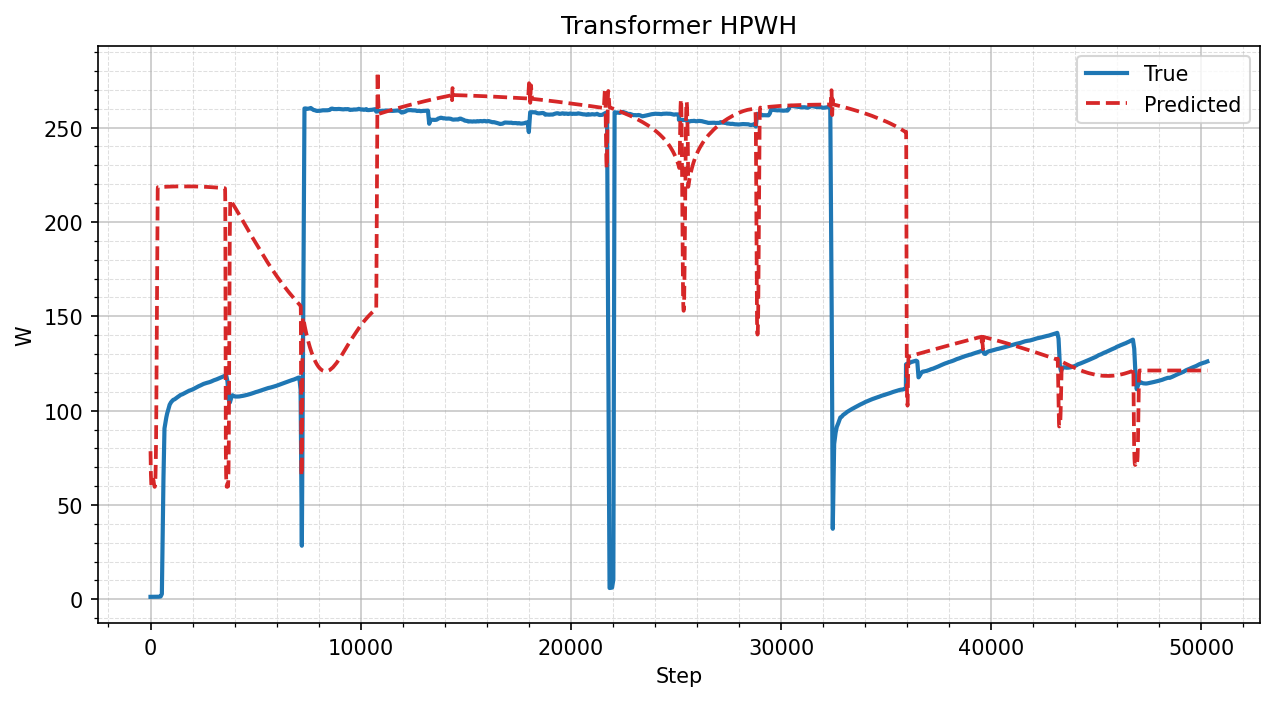

In [14]:
# hpwh_transformer.py

import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ───── Hyperparams ─────
SEQ_LEN     = 60
BATCH_SIZE  = 64
D_MODEL     = 64    # embedding dim
N_HEAD      = 4
NUM_LAYERS  = 2
DIM_FF      = 128
DROPOUT     = 0.2
LR          = 1e-3
MAX_EPOCHS  = 50
PATIENCE    = 7

FEATURES = [
    "Ambient Temp Trace(F)",
    "Inlet Temp Trace(F)",
    "Outlet Temp Trace (F)",
    "Operational Mode Code",
]
TARGET = "Power (W)"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ───── Load & Scale ─────
### Desktop
train_df = pd.read_csv(r"C:\Users\13183\Downloads\Trian 1\Trian\Merged_HPWH_Train_1s.csv")
test_df  = pd.read_csv(r"C:\Users\13183\Downloads\Test 1\Test\Merged_HPWH_Test_1s.csv")
train_df[TARGET] = -train_df[TARGET]
test_df[TARGET]  = -test_df[TARGET]
####Lab PC
# train_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv")
# test_df = pd.read_csv(r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv")

##Home PC
#train_df = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Trian\Trian\Merged_HPWH_Train_1s.csv")
#test_df  = pd.read_csv(r"C:\Users\default.DESKTOP-C4C7JDR\Downloads\Test\Test\Merged_HPWH_Test_1s.csv")

scaler_x = MinMaxScaler(); scaler_y = MinMaxScaler()
X_train = scaler_x.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).squeeze(-1)
X_test  = scaler_x.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).squeeze(-1)

# ───── Dataset ─────
class SeqDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len
    def __len__(self):
        return self.X.size(0)-self.seq_len
    def __getitem__(self, idx):
        # [seq_len, features]
        return self.X[idx:idx+self.seq_len], self.y[idx+self.seq_len]

train_dl = DataLoader(SeqDataset(X_train,y_train,SEQ_LEN), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dl  = DataLoader(SeqDataset(X_test,y_test,SEQ_LEN),  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# ───── Positional Encoding ─────
class PosEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model,2)*(-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.pe = pe.unsqueeze(0)  # [1,max_len,d_model]
    def forward(self, x):
        # x: [batch, seq_len, d_model]
        return x + self.pe[:,:x.size(1),:].to(x.device)

# ───── Model ─────
class HPWH_Transformer(nn.Module):
    def __init__(self, feature_size, d_model, nhead, num_layers, dim_ff, dropout):
        super().__init__()
        self.input_proj = nn.Linear(feature_size, d_model)
        self.pos_enc    = PosEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        # x: [batch, seq_len, features]
        x = self.input_proj(x)            # → [batch, seq_len, d_model]
        x = self.pos_enc(x)
        x = self.transformer(x)           # → [batch, seq_len, d_model]
        out = self.fc(x[:,-1,:])          # take last time step
        return out.squeeze(-1)

model = HPWH_Transformer(
    feature_size=len(FEATURES),
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_ff=DIM_FF,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ───── Train & Early Stop ─────
best_val, wait = float('inf'), 0
for epoch in range(1, MAX_EPOCHS+1):
    model.train(); tloss=0.
    for Xb,yb in tqdm(train_dl, desc=f"Trans Ep{epoch}", leave=False):
        Xb,yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss=criterion(out,yb)
        loss.backward(); optimizer.step()
        tloss+=loss.item()*Xb.size(0)
    tloss/=len(train_dl.dataset)

    model.eval(); vloss=0.
    with torch.no_grad():
        for Xb,yb in test_dl:
            Xb,yb = Xb.to(device), yb.to(device)
            vloss+=criterion(model(Xb),yb).item()*Xb.size(0)
    vloss/=len(test_dl.dataset)

    print(f"[Trans] Ep{epoch:02d} Train MSE:{tloss:.5f} Val MSE:{vloss:.5f}")
    if vloss<best_val: best_val,wait=vloss,0; torch.save(model.state_dict(),"best_trans.pt")
    else:
        wait+=1
        if wait>=PATIENCE:
            print("Early stopping Transformer."); break

# ───── Evaluate ─────
model.load_state_dict(torch.load("best_trans.pt")); model.eval()
yt,yp=[],[]
with torch.no_grad():
    for Xb,yb in test_dl:
        out = model(Xb.to(device)).cpu().numpy()
        yp.append(out); yt.append(yb.numpy())
yt = scaler_y.inverse_transform(np.concatenate(yt).reshape(-1,1)).ravel()
yp = scaler_y.inverse_transform(np.concatenate(yp).reshape(-1,1)).ravel()

mae  = mean_absolute_error(yt, yp)
rmse = np.sqrt(mean_squared_error(yt, yp))
r2   = r2_score(yt, yp)
nrmse = rmse / (yt.max() - yt.min())

print(f"\nTest MAE: {mae:.2f} W | RMSE: {rmse:.2f} W | NRMSE: {nrmse:.4f} | R^2: {r2:.3f}")


# plt.figure(); plt.plot(yp,label="Pred"); plt.plot(yt,label="True")
# ───── Plot predicted vs. actual ─────
plt.figure(figsize=(10, 5), dpi=150)

# Colors/linestyles to match your reference:
#   - True:   blue solid
#   - Predicted: red dashed
plt.plot(y_true, label="True", color="tab:blue", linewidth=2.0)
plt.plot(y_pred, label="Predicted", color="tab:red", linestyle="--", linewidth=1.8)

# Grid styling (major + minor)
ax = plt.gca()
ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.7)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.title("Transformer HPWH"); plt.xlabel("Step"); plt.ylabel("W"); plt.legend(); plt.show()

### Energy Comsumption Analysis

In [ ]:
#  Load & preprocess dataset
train_df = pd.read_csv(
    r"C:\Users\jliu359\Downloads\Hpwh\Train\Train\Merged_HPWH_Train_1s.csv",
    parse_dates=["Timestamp"]
)
test_df = pd.read_csv(
    r"C:\Users\jliu359\Downloads\Hpwh\Test\Test\Merged_HPWH_Test_1s.csv",
    parse_dates=["Timestamp"]
)
for df in (train_df, test_df):
    df["Energy_Wh"] = df["Power (W)"].abs() / 3600.0
    df["Date"]      = df["Timestamp"].dt.date

def daily_mode_energy(df):
    agg = (
        df
        .groupby(["Date", "Operational Mode Code"])["Energy_Wh"]
        .sum()
        .reset_index()
    )
    agg["Energy_kWh"] = agg["Energy_Wh"] / 1000.0
    return agg

train_daily = daily_mode_energy(train_df)
test_daily  = daily_mode_energy(test_df)

#  Create pivot tables
train_pivot = train_daily.pivot(
    index="Date",
    columns="Operational Mode Code",
    values="Energy_kWh"
).fillna(0)

test_pivot = test_daily.pivot(
    index="Date",
    columns="Operational Mode Code",
    values="Energy_kWh"
).fillna(0)

# Ensure both have the same mode columns
all_modes = sorted(set(train_pivot.columns) | set(test_pivot.columns))
train_pivot = train_pivot.reindex(columns=all_modes, fill_value=0)
test_pivot  = test_pivot.reindex(columns=all_modes, fill_value=0)

# Define colors for each mode
mode_colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
colors = [mode_colors.get(m, "tab:gray") for m in all_modes]

# Plot TRAIN with explicit colors
ax = train_pivot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12, 6),
    width=0.8,
    edgecolor="black"
)
ax.set_xlabel("Date")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Train: Daily Energy Consumption by Mode")
ax.legend(title="Operational Mode Code", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot TEST with the same colors
ax = test_pivot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12, 6),
    width=0.8,
    edgecolor="black"
)
ax.set_xlabel("Date")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Test: Daily Energy Consumption by Mode")
ax.legend(title="Operational Mode Code", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()